# Fake Job Description Prediction
This dataset contains 18K job descriptions out of which about 800 are fake. The data consists of both textual information and meta-information about the jobs. The dataset can be used to create classification models which can learn the job descriptions which are fraudulent.

In [1]:
"""Importing libraries"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('fivethirtyeight')

from tqdm import tqdm
import time
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold,KFold, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
import xgboost as xgb
from sklearn import preprocessing, model_selection, pipeline
from sklearn.metrics import f1_score, roc_auc_score

from keras.models import Sequential
from keras.layers import (
    LSTM, GRU,
    Dense, Activation, Dropout,
    Embedding,
    BatchNormalization,
    GlobalMaxPooling1D, Conv1D, MaxPooling1D, Flatten,
    Bidirectional,
    SpatialDropout1D
)
from keras.utils import to_categorical
from keras.callbacks import EarlyStopping

# 先只保留 sequence，拿掉 text
from keras.preprocessing import sequence

2026-04-01 11:57:52.601835: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775044672.952990      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775044673.049909      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775044673.913831      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775044673.913865      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775044673.913868      55 computation_placer.cc:177] computation placer alr

In [2]:
# ===== 保存目录（Kaggle / Colab 自动适配）=====
import os
import json
import joblib
from pathlib import Path

if os.path.exists("/kaggle/working"):
    ARTIFACT_DIR = Path("/kaggle/working/fake_job_mvp")
else:
    ARTIFACT_DIR = Path("/content/fake_job_mvp")

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
print("模型保存目录:", ARTIFACT_DIR)

模型保存目录: /kaggle/working/fake_job_mvp


In [3]:
df = pd.read_csv("../input/real-or-fake-fake-jobposting-prediction/fake_job_postings.csv")
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [4]:
"""Missing values"""
df.isnull().sum()

job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64

In [5]:
"""Extracting Text Featurs"""

text_df = df[["title", "company_profile", "description", "requirements", "benefits","fraudulent"]]
text_df = text_df.fillna(' ')

text_df.head()

,title,company_profile,description,requirements,benefits,fraudulent
0,Marketing Intern,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,,0
1,Customer Service - Cloud Video Production,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0
2,Commissioning Machinery Assistant (CMA),Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,,0
3,Account Executive - Washington DC,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0
4,Bill Review Manager,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0


In [6]:
"""Catagorical Feature"""
cat_df = df[["telecommuting", "has_company_logo", "has_questions", "employment_type", "required_experience", "required_education", "industry", "function","fraudulent"]]
cat_df = cat_df.fillna("None")

cat_df.head()

,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,0,1,0,Other,Internship,None,None,Marketing,0
1,0,1,0,Full-time,Not Applicable,None,Marketing and Advertising,Customer Service,0
2,0,1,0,None,None,None,None,None,0
3,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


# Target

/tmp/ipykernel_55/1207650957.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["Real Post (17014) [0's]", "Fake Post (866) [1's]"])


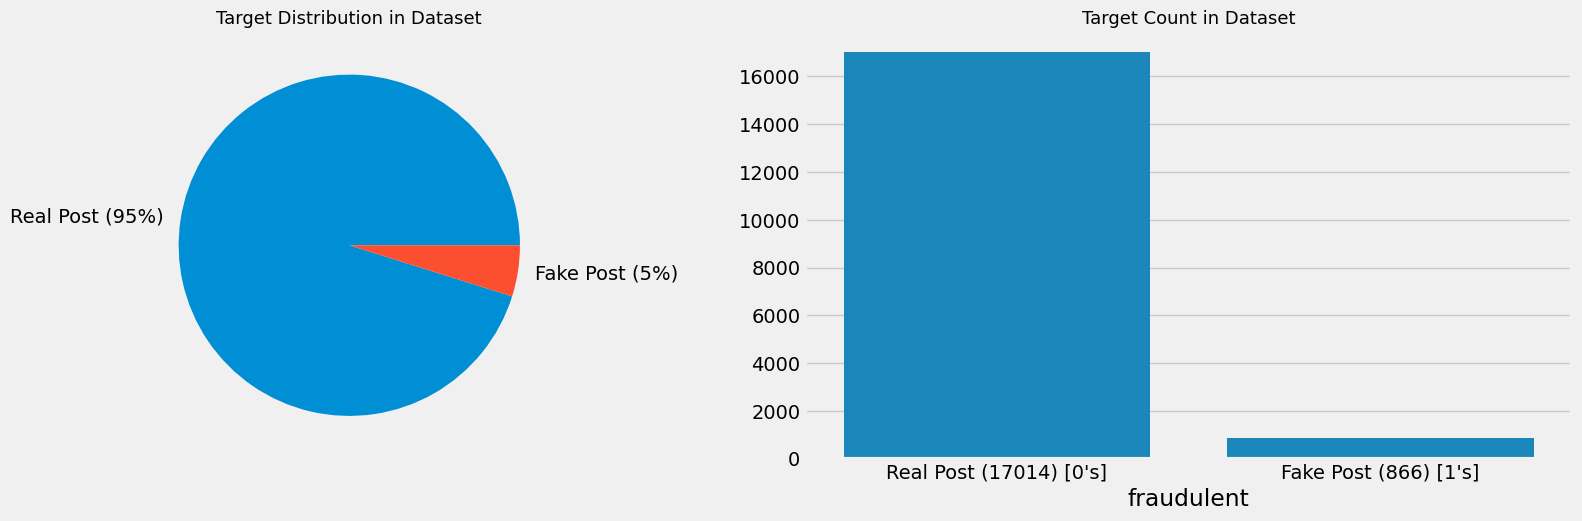

In [7]:
fig, axes = plt.subplots(ncols=2, figsize=(17, 5), dpi=100)
plt.tight_layout()

df["fraudulent"].value_counts().plot(kind='pie', ax=axes[0], labels=['Real Post (95%)', 'Fake Post (5%)'])
temp = df["fraudulent"].value_counts()
sns.barplot(x=temp.index, y=temp.values, ax=axes[1])

axes[0].set_ylabel(' ')
axes[1].set_ylabel(' ')
axes[1].set_xticklabels(["Real Post (17014) [0's]", "Fake Post (866) [1's]"])

axes[0].set_title('Target Distribution in Dataset', fontsize=13)
axes[1].set_title('Target Count in Dataset', fontsize=13)

plt.show()

Hmm!! Class distributions are **95% for 0 (Real Post)** and **5% for 1 (Fake Post).** Target distribution is highly imbalanced. Accuracy metric is not useful here it will mislead the result. So, we've to look into Precision, Recall, F1 Score for model evalution.

# Exploratory Data Analysis of tweets

/tmp/ipykernel_55/1456831904.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xlabels,  fontsize=10)
/tmp/ipykernel_55/1456831904.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ylabels,  fontsize=10)
/tmp/ipykernel_55/1456831904.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xlabels,  fontsize=10)
/tmp/ipykernel_55/1456831904.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ylabels,  fontsize=10)
/tmp/ipykernel_55/1456831904.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax

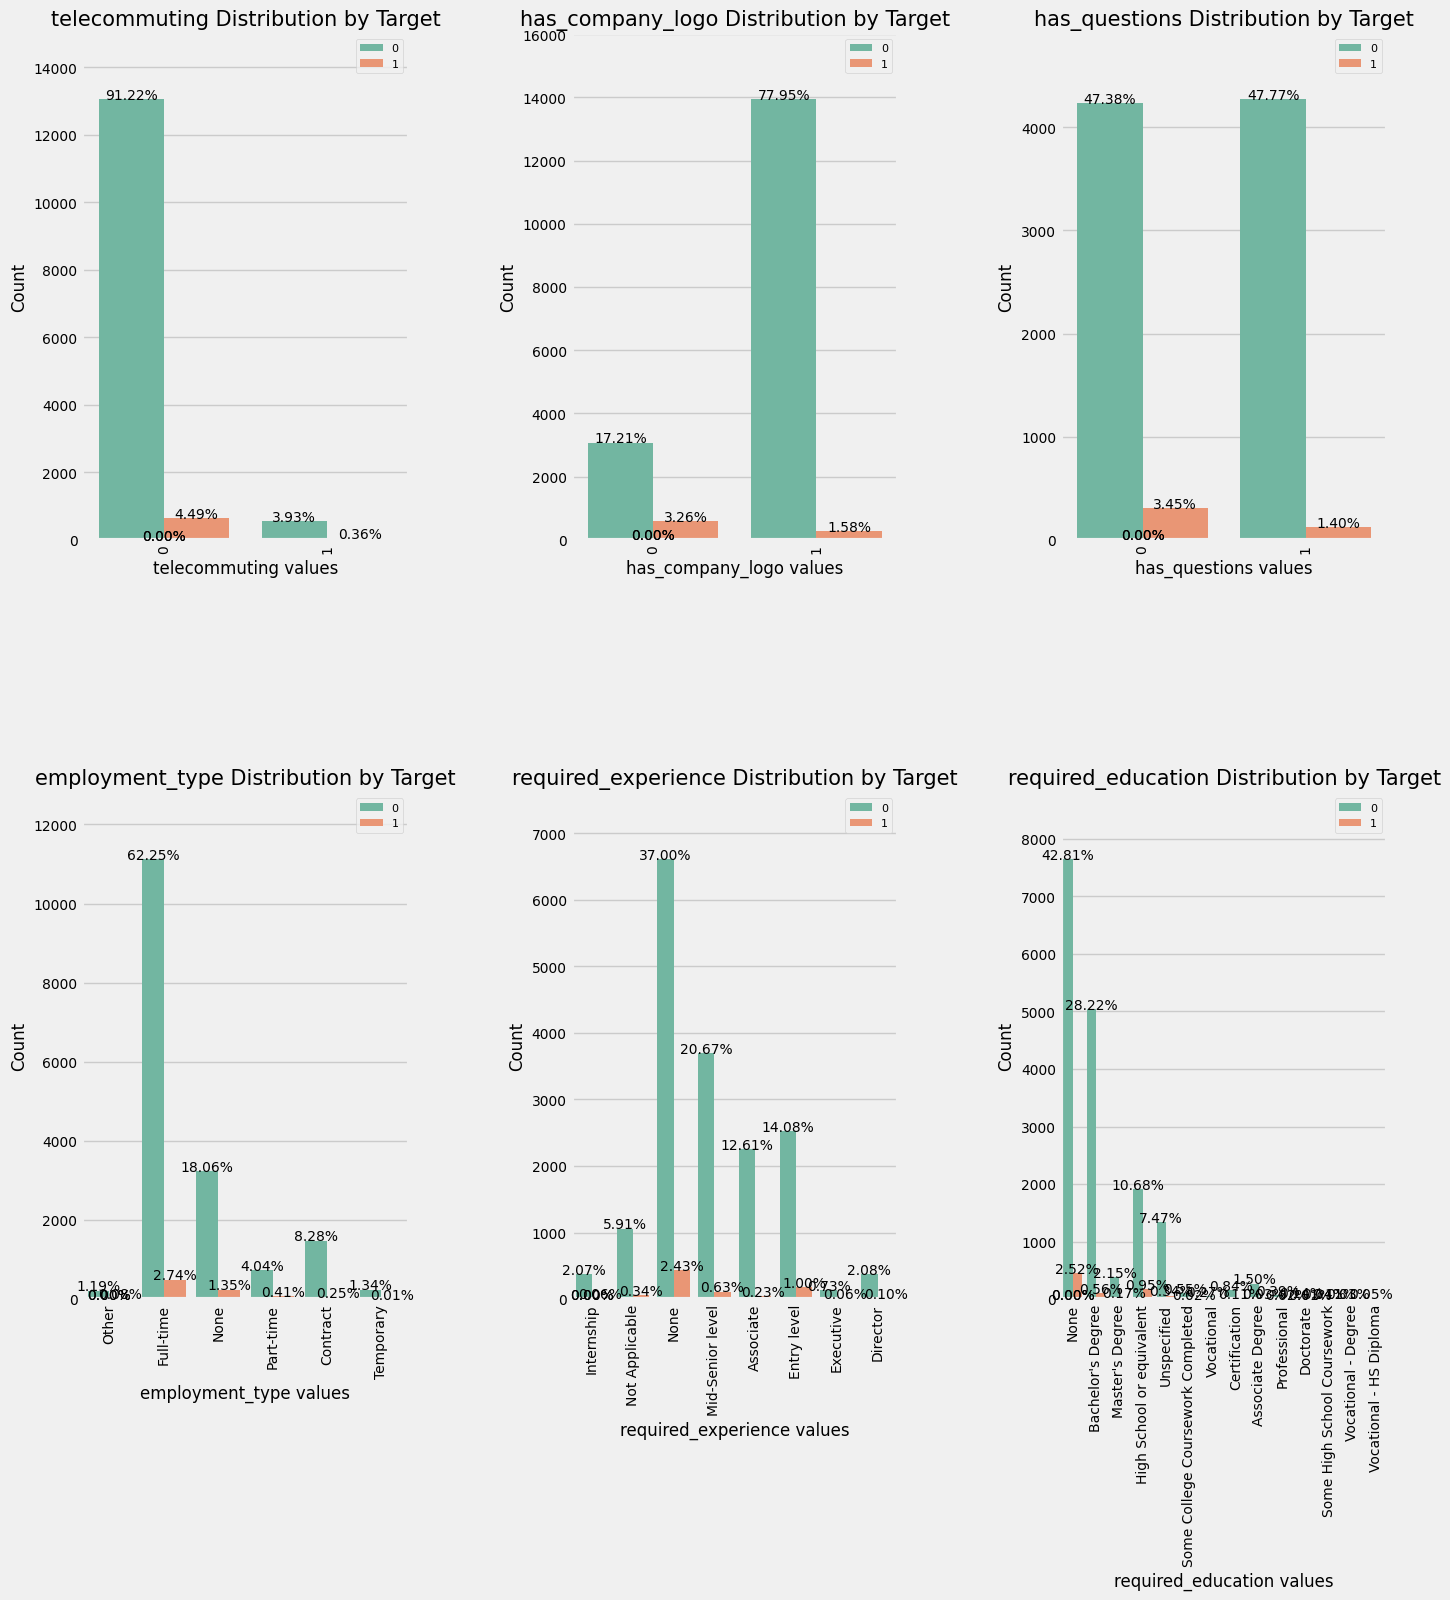

In [8]:
cat_cols = ["telecommuting", "has_company_logo", "has_questions", "employment_type", "required_experience", "required_education",]
# visualizating catagorical variable by target
import matplotlib.gridspec as gridspec # to do the grid of plots
grid = gridspec.GridSpec(3, 3, wspace=0.5, hspace=0.5) # The grid of chart
plt.figure(figsize=(15,25)) # size of figure

# loop to get column and the count of plots
for n, col in enumerate(cat_df[cat_cols]): 
    ax = plt.subplot(grid[n]) # feeding the figure of grid
    sns.countplot(x=col, data=cat_df, hue='fraudulent', palette='Set2') 
    ax.set_ylabel('Count', fontsize=12) # y axis label
    ax.set_title(f'{col} Distribution by Target', fontsize=15) # title label
    ax.set_xlabel(f'{col} values', fontsize=12) # x axis label
    xlabels = ax.get_xticklabels() 
    ylabels = ax.get_yticklabels() 
    ax.set_xticklabels(xlabels,  fontsize=10)
    ax.set_yticklabels(ylabels,  fontsize=10)
    plt.legend(fontsize=8)
    plt.xticks(rotation=90) 
    total = len(cat_df)
    sizes=[] # Get highest values in y
    for p in ax.patches: # loop to all objects
        height = p.get_height()
        sizes.append(height)
        ax.text(p.get_x()+p.get_width()/2.,
                height + 3,
                '{:1.2f}%'.format(height/total*100),
                ha="center", fontsize=10) 
    ax.set_ylim(0, max(sizes) * 1.15) #set y limit based on highest heights


plt.show()


## Number of characters
Let's compare the number of character in the fake post and real post and try to distinguish pattern in the fake and real post based on number of charater used in the post.

#### Company profile
We can see that **fake post has less characters** in the company profile while **real post has more charaters.**

#### Description

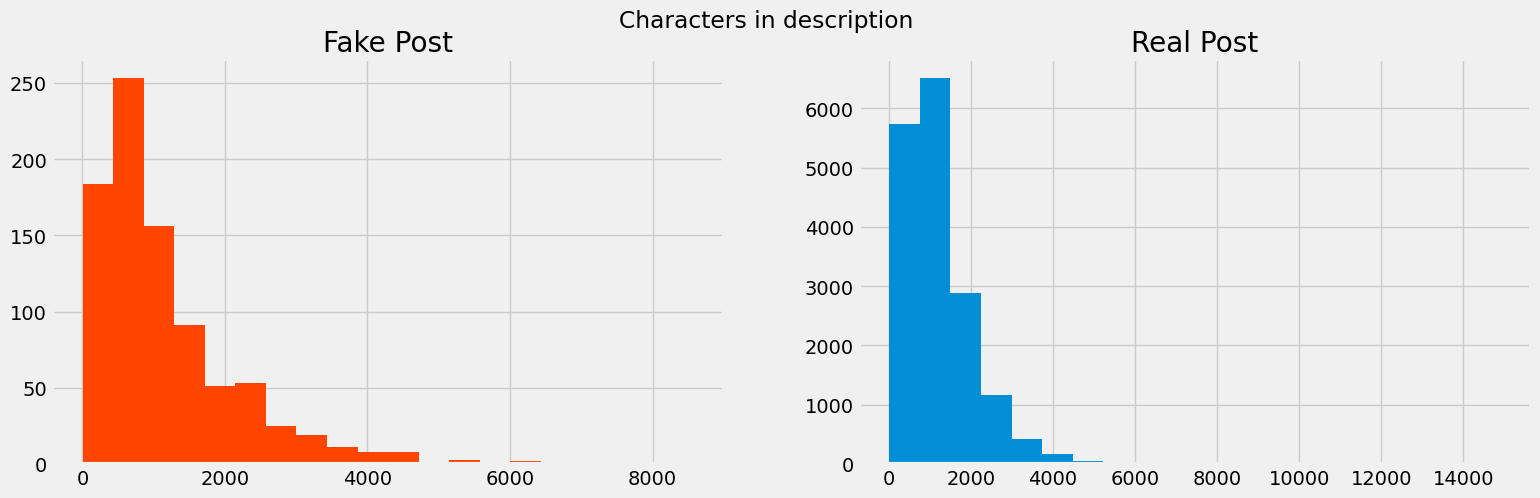

In [9]:
fig,(ax1,ax2)= plt.subplots(ncols=2, figsize=(17, 5), dpi=100)
length=text_df[text_df["fraudulent"]==1]['description'].str.len()
ax1.hist(length,bins = 20,color='orangered')
ax1.set_title('Fake Post')
length=text_df[text_df["fraudulent"]==0]['description'].str.len()
ax2.hist(length, bins = 20)
ax2.set_title('Real Post')
fig.suptitle('Characters in description')
plt.show()

The distribution of charaters in description of the fake and real post are similar but some fake post reach to 6000 to 6500 characters. 

#### Requirements

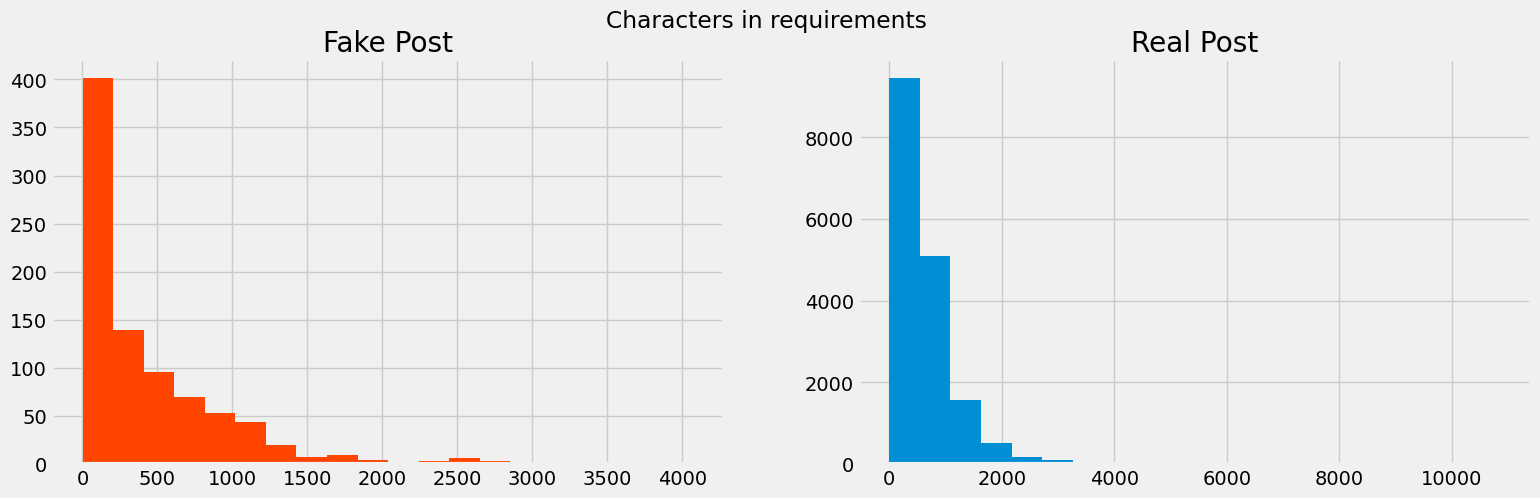

In [10]:
fig,(ax1,ax2)= plt.subplots(ncols=2, figsize=(17, 5), dpi=100)
length=text_df[text_df["fraudulent"]==1]['requirements'].str.len()
ax1.hist(length,bins = 20,color='orangered')
ax1.set_title('Fake Post')
length=text_df[text_df["fraudulent"]==0]['requirements'].str.len()
ax2.hist(length,bins = 20)
ax2.set_title('Real Post')
fig.suptitle('Characters in requirements')
plt.show()

The distribution of charaters in requirements of the fake and real post are similar.

#### Benefits

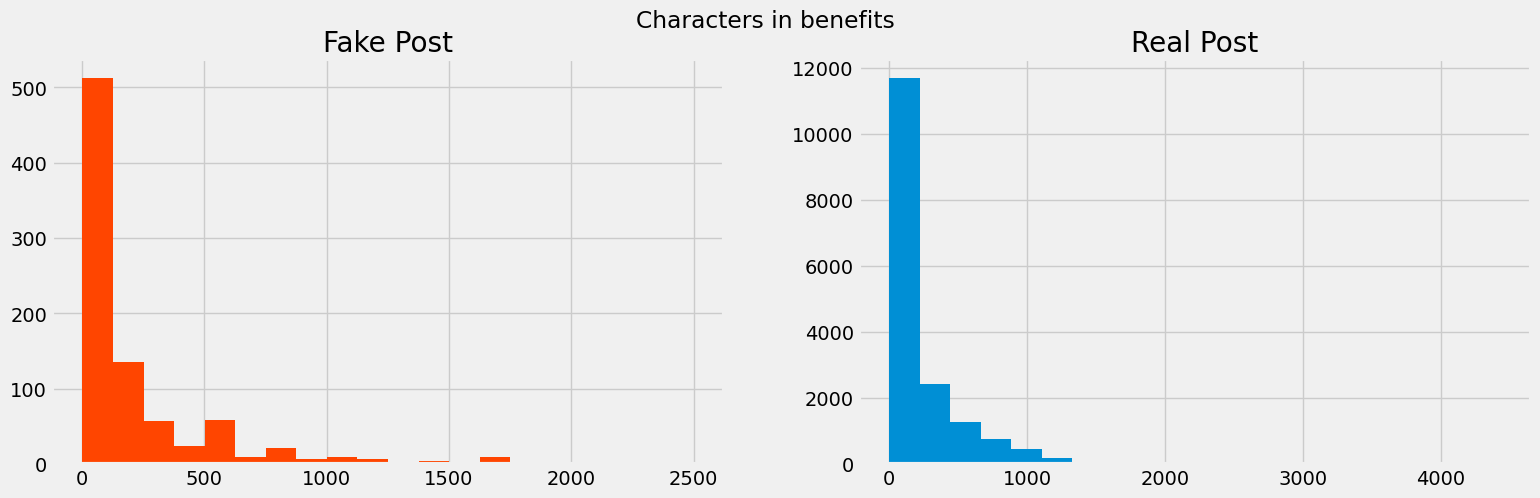

In [11]:
fig,(ax1,ax2)= plt.subplots(ncols=2, figsize=(17, 5), dpi=100)
length=text_df[text_df["fraudulent"]==1]['benefits'].str.len()
ax1.hist(length,bins = 20,color='orangered')
ax1.set_title('Fake Post')
length=text_df[text_df["fraudulent"]==0]['benefits'].str.len()
ax2.hist(length,bins = 20)
ax2.set_title('Real Post')
fig.suptitle('Characters in benefits')
plt.show()

The distribution of charaters in requirements of the fake and real post is same around 1500 to 1800.

## Number of words
Let's compare the number of words in the fake post and real post and try to distinguish pattern in the fake and real post based on number of words used in the post.

#### Company Profile

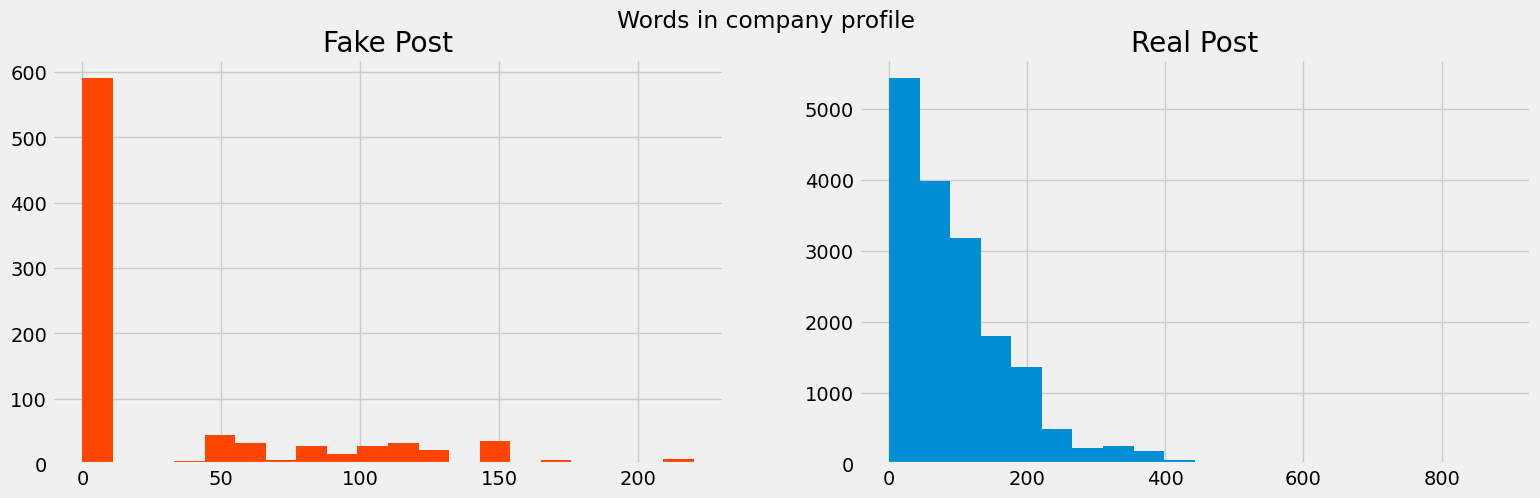

In [12]:
fig,(ax1,ax2)= plt.subplots(ncols=2, figsize=(17, 5), dpi=100)
num=text_df[text_df["fraudulent"]==1]['company_profile'].str.split().map(lambda x: len(x))
ax1.hist(num,bins = 20,color='orangered')
ax1.set_title('Fake Post')
num=text_df[text_df["fraudulent"]==0]['company_profile'].str.split().map(lambda x: len(x))
ax2.hist(num, bins = 20)
ax2.set_title('Real Post')
fig.suptitle('Words in company profile')
plt.show()

Pattern of words in company profile is same as character in company profile. **fake post has less words** in the company profile while **real post has more words.**

#### Description

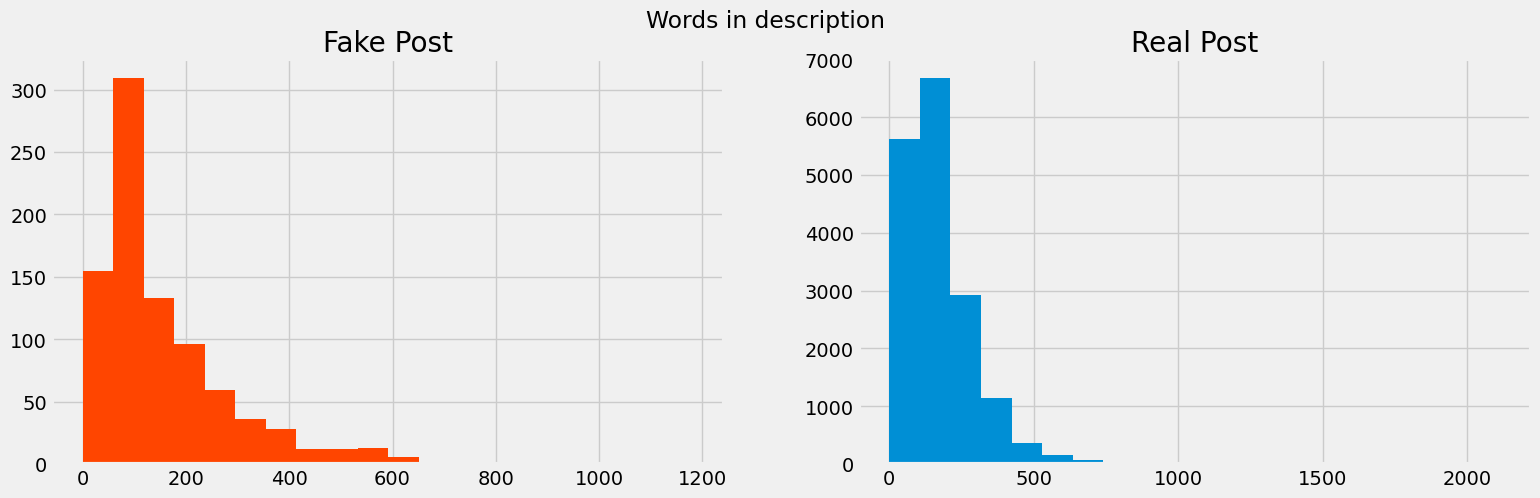

In [13]:
fig,(ax1,ax2)= plt.subplots(ncols=2, figsize=(17, 5), dpi=100)
num=text_df[text_df["fraudulent"]==1]['description'].str.split().map(lambda x: len(x))
ax1.hist(num,bins = 20,color='orangered')
ax1.set_title('Fake Post')
num=text_df[text_df["fraudulent"]==0]['description'].str.split().map(lambda x: len(x))
ax2.hist(num, bins = 20)
ax2.set_title('Real Post')
fig.suptitle('Words in description')
plt.show()

Hmm!! Both the post has similar distribution of words in description.

#### Requirements

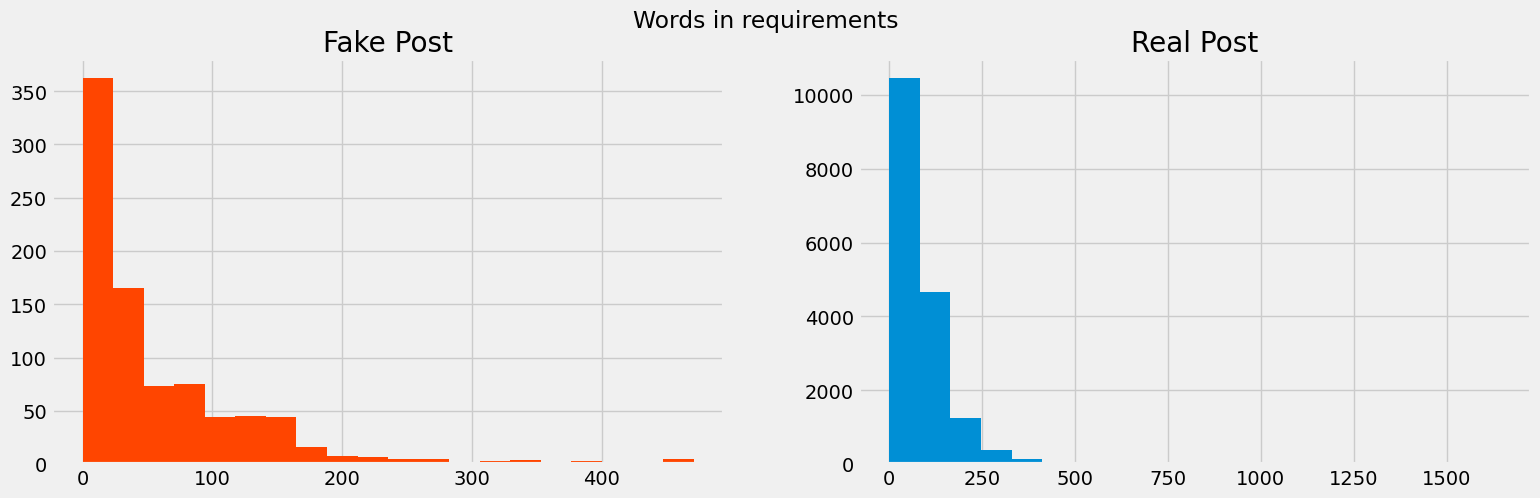

In [14]:
fig,(ax1,ax2)= plt.subplots(ncols=2, figsize=(17, 5), dpi=100)
num=text_df[text_df["fraudulent"]==1]['requirements'].str.split().map(lambda x: len(x))
ax1.hist(num,bins = 20,color='orangered')
ax1.set_title('Fake Post')
num=text_df[text_df["fraudulent"]==0]['requirements'].str.split().map(lambda x: len(x))
ax2.hist(num,bins = 20)
ax2.set_title('Real Post')
fig.suptitle('Words in requirements')
plt.show()

The distribution of words in requirements of the fake and real post are similar.

#### Benefits

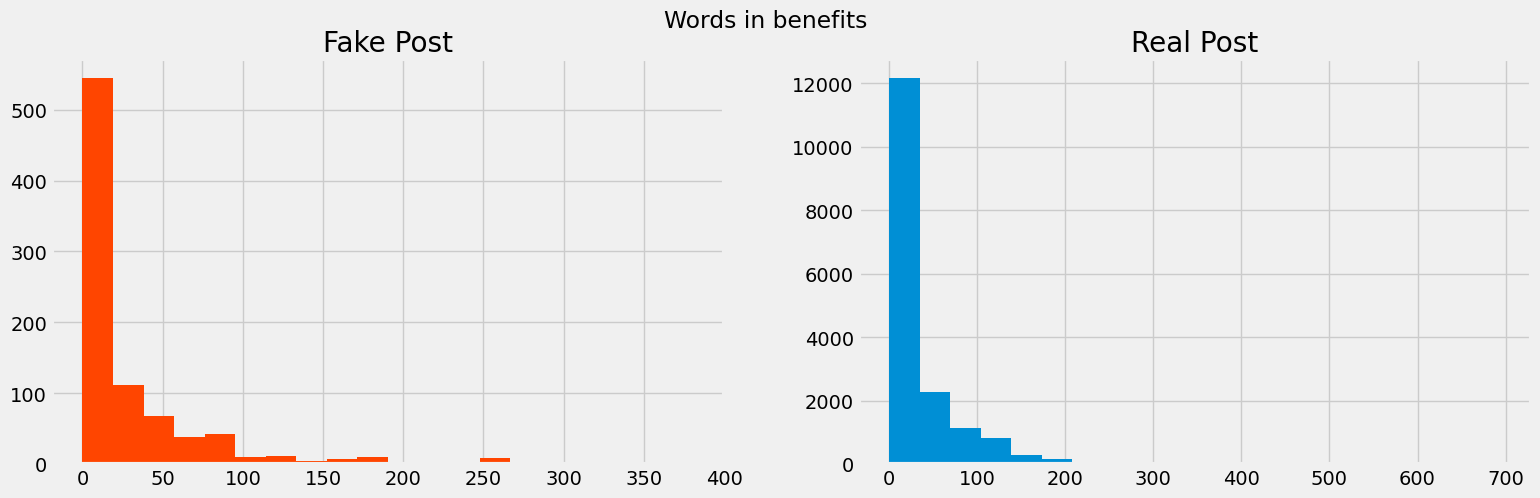

In [15]:
fig,(ax1,ax2)= plt.subplots(ncols=2, figsize=(17, 5), dpi=100)
num=text_df[text_df["fraudulent"]==1]['benefits'].str.split().map(lambda x: len(x))
ax1.hist(num,bins = 20,color='orangered')
ax1.set_title('Fake Post')
num=text_df[text_df["fraudulent"]==0]['benefits'].str.split().map(lambda x: len(x))
ax2.hist(num, bins = 20)
ax2.set_title('Real Post')
fig.suptitle('Words in benefits')
plt.show()

The distribution of words in benefits of the fake and real post are also similar.

# Data preprocessing

In [16]:
"""Concate the text data for preprocessing and modeling"""
text = text_df[text_df.columns[0:-1]].apply(lambda x: ','.join(x.dropna().astype(str)),axis=1)
target = df['fraudulent']

print(len(text))
print(len(target))

17880
17880


## Ngrams Analysis

Most common unigrams exist in **both classes** are mostly punctuations, stop words or numbers. It is better to clean them before modelling since they don't give much information about target.

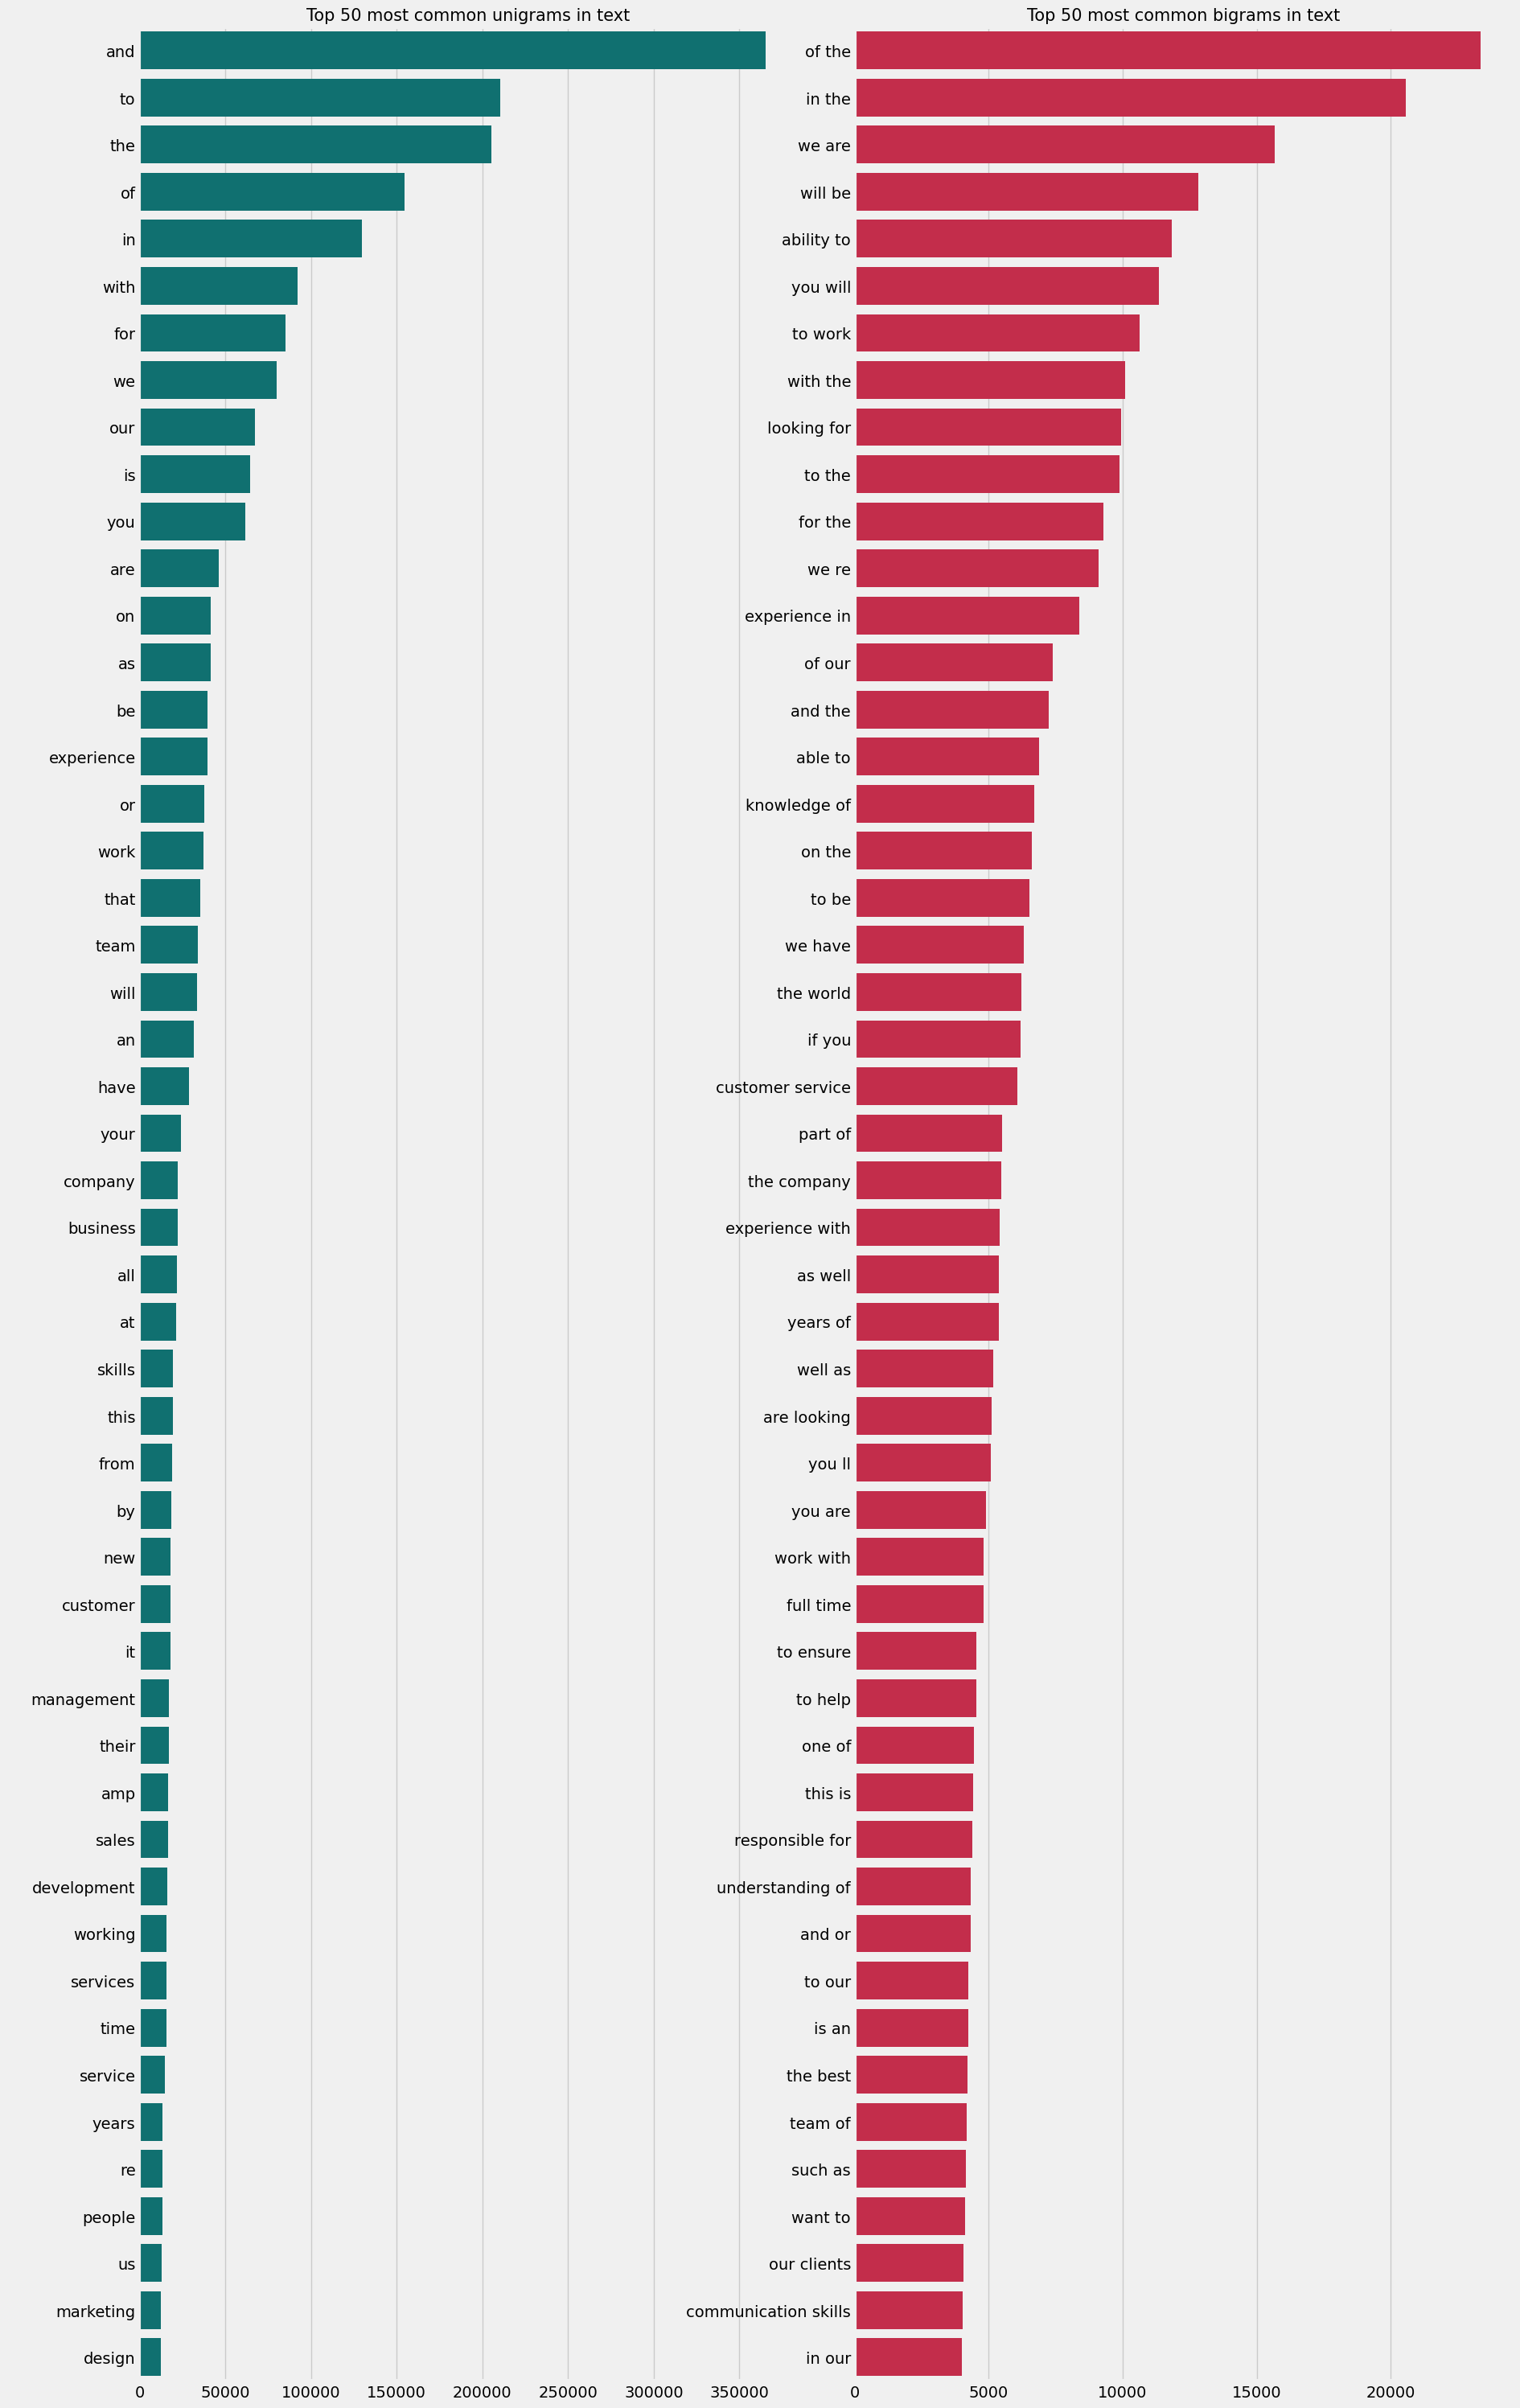

In [17]:
def get_top_tweet_unigrams(corpus, n=None):
    vec = CountVectorizer(ngram_range=(1, 1)).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq =sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:n]

def get_top_tweet_bigrams(corpus, n=None):
    vec = CountVectorizer(ngram_range=(2, 2)).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq =sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:n]

fig, axes = plt.subplots(ncols=2, figsize=(18, 30), dpi=100)
plt.tight_layout()

top_unigrams=get_top_tweet_unigrams(text)[:50]
x,y=map(list,zip(*top_unigrams))
sns.barplot(x=y,y=x, ax=axes[0], color='teal')


top_bigrams=get_top_tweet_bigrams(text)[:50]
x,y=map(list,zip(*top_bigrams))
sns.barplot(x=y,y=x, ax=axes[1], color='crimson')


axes[0].set_ylabel(' ')
axes[1].set_ylabel(' ')

axes[0].set_title('Top 50 most common unigrams in text', fontsize=15)
axes[1].set_title('Top 50 most common bigrams in text', fontsize=15)

plt.show()

## Text cleaning

In [18]:
%%time
def clean_text(text):
    '''Make text lowercase, remove text in square brackets,remove links,remove punctuation
    and remove words containing numbers.'''
    text = text.lower()
    text = re.sub('\[.*?\]', '', text)
    text = re.sub('https?://\S+|www\.\S+', '', text)
    text = re.sub('<.*?>+', '', text)
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub('\n', '', text)
    text = re.sub('\w*\d\w*', '', text)
    return text


# Applying the cleaning function to both test and training datasets
text = text.apply(lambda x: clean_text(x))
text.head(3)

<unknown>:5: SyntaxWarning: invalid escape sequence '\['
<unknown>:6: SyntaxWarning: invalid escape sequence '\S'
<unknown>:10: SyntaxWarning: invalid escape sequence '\w'


CPU times: user 8.63 s, sys: 32.9 ms, total: 8.66 s
Wall time: 8.66 s


0    marketing internwere  and weve created a groun...
1    customer service  cloud video  seconds the wor...
2    commissioning machinery assistant cmavalor ser...
dtype: object

## Tokenizer

In [19]:
%%time
tokenizer = nltk.tokenize.RegexpTokenizer(r'\w+')

# appling tokenizer5
text = text.apply(lambda x: tokenizer.tokenize(x))
text.head(3)

CPU times: user 1.93 s, sys: 147 ms, total: 2.08 s
Wall time: 2.07 s


0    [marketing, internwere, and, weve, created, a,...
1    [customer, service, cloud, video, seconds, the...
2    [commissioning, machinery, assistant, cmavalor...
dtype: object

In [20]:
%%time
stop_words = stopwords.words('english')
def remove_stopwords(text):
    """
    Removing stopwords belonging to english language
    
    """
    words = [w for w in text if w not in stop_words]
    return words


text = text.apply(lambda x : remove_stopwords(x))

CPU times: user 9.44 s, sys: 6.65 ms, total: 9.45 s
Wall time: 9.46 s


In [21]:
%%time
def combine_text(list_of_text):
    combined_text = ' '.join(list_of_text)
    return combined_text

text = text.apply(lambda x : combine_text(x))
text.head(3)

CPU times: user 146 ms, sys: 16.1 ms, total: 162 ms
Wall time: 160 ms


0    marketing internwere weve created groundbreaki...
1    customer service cloud video seconds worlds cl...
2    commissioning machinery assistant cmavalor ser...
dtype: object

# Baseline Model

In [22]:
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=2)
auc_buf = []   
cnt = 0
predictions = 0
# enumerate the splits and summarize the distributions
for train_ix, test_ix in kfold.split(text, target):
    print('Fold {}'.format(cnt + 1))
    train_X, test_X = text[train_ix], text[test_ix]
    train_y, test_y = target[train_ix], target[test_ix]

    # Appling Count Vectorizer
    count_vectorizer = CountVectorizer()
    train_X_vec = count_vectorizer.fit_transform(train_X)
    test_X_vec = count_vectorizer.transform(test_X)    
    
    lr = LogisticRegression(C=0.1, solver='lbfgs', max_iter=1000, verbose=0, n_jobs=-1)
    lr.fit(train_X_vec, train_y)
    preds = lr.predict(test_X_vec)
    
    auc = roc_auc_score(test_y, preds)
    print('{} AUC: {}'.format(cnt, auc))
    auc_buf.append(auc)
    cnt += 1

print('AUC mean score = {:.6f}'.format(np.mean(auc_buf)))
print('AUC std score = {:.6f}'.format(np.std(auc_buf)))

Fold 1
0 AUC: 0.8457923049876087
Fold 2
1 AUC: 0.8517195809885532
Fold 3
2 AUC: 0.8283043353450458
Fold 4
3 AUC: 0.8720977240415205
Fold 5
4 AUC: 0.8611871313020738
AUC mean score = 0.851820
AUC std score = 0.014753


In [50]:
# ===== 单条文本预处理函数（供训练后验证 / 未来 web 使用）=====

def preprocess_single_text(raw_text):
    # 1) clean_text
    x = str(raw_text).lower()
    x = re.sub(r'\[.*?\]', '', x)
    x = re.sub(r'https?://\S+|www\.\S+', '', x)
    x = re.sub(r'<.*?>+', '', x)
    x = re.sub(r'[%s]' % re.escape(string.punctuation), '', x)
    x = re.sub(r'\n', ' ', x)
    x = re.sub(r'\w*\d\w*', '', x)

    # 2) tokenize
    tokens = tokenizer.tokenize(x)

    # 3) remove stopwords
    tokens = [w for w in tokens if w not in stop_words]

    # 4) combine
    x = ' '.join(tokens)
    return x


def build_raw_text_from_fields(title="", company_profile="", description="", requirements="", benefits=""):
    parts = [title, company_profile, description, requirements, benefits]
    parts = [str(p).strip() for p in parts if str(p).strip()]
    return ",".join(parts)

In [23]:
# ===== 训练最终 MVP baseline 模型（全量数据）并保存 =====

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression

# text 和 target 用你前面已经处理好的最终变量
# text: 已完成清洗、分词、去停用词、重新拼接后的文本
# target: df['fraudulent']

X_all = text.astype(str).values
y_all = target.astype(int).values

final_vectorizer = CountVectorizer()
X_all_vec = final_vectorizer.fit_transform(X_all)

final_lr = LogisticRegression(
    C=0.1,
    solver='lbfgs',
    max_iter=1000,
    n_jobs=-1
)
final_lr.fit(X_all_vec, y_all)

# 保存
joblib.dump(final_vectorizer, ARTIFACT_DIR / "count_vectorizer.joblib")
joblib.dump(final_lr, ARTIFACT_DIR / "logreg_model.joblib")

metadata = {
    "model_type": "CountVectorizer + LogisticRegression",
    "text_fields": ["title", "company_profile", "description", "requirements", "benefits"],
    "target_col": "fraudulent",
    "preprocess": [
        "lowercase",
        "remove_links",
        "remove_html",
        "remove_punctuation",
        "remove_digits_words",
        "regexp_tokenize",
        "remove_english_stopwords",
        "join_tokens_with_space"
    ]
}

with open(ARTIFACT_DIR / "metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print("保存完成：")
print(ARTIFACT_DIR / "count_vectorizer.joblib")
print(ARTIFACT_DIR / "logreg_model.joblib")
print(ARTIFACT_DIR / "metadata.json")

保存完成：
/kaggle/working/fake_job_mvp/count_vectorizer.joblib
/kaggle/working/fake_job_mvp/logreg_model.joblib
/kaggle/working/fake_job_mvp/metadata.json


In [51]:
# ===== 加载模型并做一次单条预测验证 =====

loaded_vectorizer = joblib.load(ARTIFACT_DIR / "count_vectorizer.joblib")
loaded_model = joblib.load(ARTIFACT_DIR / "logreg_model.joblib")

sample_raw = build_raw_text_from_fields(
    title="Data Entry Clerk",
    company_profile="Fast growing online company",
    description="Work from home and earn money quickly, no experience needed",
    requirements="Basic computer skills",
    benefits="Flexible hours and huge commissions"
)

sample_processed = preprocess_single_text(sample_raw)
sample_vec = loaded_vectorizer.transform([sample_processed])

pred_label = loaded_model.predict(sample_vec)[0]
pred_prob = loaded_model.predict_proba(sample_vec)[0, 1]

print("处理后文本:", sample_processed[:200], "...")
print("预测标签:", int(pred_label))
print("诈骗概率:", float(pred_prob))

处理后文本: data entry clerk ##fast growing online company ##work home earn money quickly experience needed ##bas ##ic computer skills ##fle ##xi ##ble hours huge commissions ...
预测标签: 0
诈骗概率: 0.4048364016131716


It's seem simple Logistic Regression model perform well. **AUC mean score of 0.85** demonstrating the good fitting of chosen model. Let's apply Glove for vectorization with deep learning.

# GloVe ¶
Here we will use GloVe pretrained corpus model to represent our words.It is available in 3 varieties :50D ,100D and 200 Dimentional.We will try 200 D here.

In [25]:
# spliting tthe data for glove
X_train, X_test, y_train, y_test = train_test_split(text, target, test_size=0.2, random_state=4, stratify=target)

In [26]:
"""Load the Glove vectors in a dictionay"""
embeddings_index={}
with open('../input/glove-global-vectors-for-word-representation/glove.6B.200d.txt','r') as f:
    for line in f:
        values=line.split()
        word=values[0]
        vectors=np.asarray(values[1:],'float32')
        embeddings_index[word]=vectors
f.close()

print('Found %s word vectors.' % len(embeddings_index))

Found 400000 word vectors.


In [27]:
""" Function Creates a normalized vector for the whole sentence"""
def sent2vec(s):
    words = str(s).lower()
    words = word_tokenize(words)
    words = [w for w in words if not w in stop_words]
    words = [w for w in words if w.isalpha()]
    M = []
    for w in words:
        try:
            M.append(embeddings_index[w])
        except:
            continue
    M = np.array(M)
    v = M.sum(axis=0)
    if type(v) != np.ndarray:
        return np.zeros(200)
    return v / np.sqrt((v ** 2).sum())

In [28]:
# create glove features
xtrain_glove = np.array([sent2vec(x) for x in tqdm(X_train)])
xtest_glove = np.array([sent2vec(x) for x in tqdm(X_test)])

100%|██████████| 3576/3576 [00:05<00:00, 686.45it/s]


# Deep Learning 
## Sequential Neural Net 

In [29]:
"""scale the data before any neural net"""
scl = preprocessing.StandardScaler()
xtrain_glove_scl = scl.fit_transform(xtrain_glove)
xtest_glove_scl = scl.transform(xtest_glove)

In [30]:
"""create a simple 2 layer sequential neural net"""
model = Sequential()

model.add(Dense(200, input_dim=200, activation='relu'))
model.add(Dropout(0.2))
model.add(BatchNormalization())

model.add(Dense(100, activation='relu'))
model.add(Dropout(0.2))
model.add(BatchNormalization())

model.add(Dense(100, activation='relu'))
model.add(Dropout(0.2))
model.add(BatchNormalization())

model.add(Dense(1))
model.add(Activation('sigmoid'))

# compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1775044846.351131      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775044846.354017      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [31]:
model.fit(xtrain_glove_scl, y=y_train, batch_size=64, 
          epochs=10, verbose=1, 
          validation_data=(xtest_glove_scl, y_test))

Epoch 1/10


I0000 00:00:1775044850.312100     164 service.cc:152] XLA service 0x7fad64013640 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775044850.312132     164 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775044850.312135     164 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775044850.886713     164 cuda_dnn.cc:529] Loaded cuDNN version 91002


 68/224 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5911 - loss: 0.7452

I0000 00:00:1775044853.368435     164 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


224/224 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.7226 - loss: 0.5645 - val_accuracy: 0.9667 - val_loss: 0.1329
Epoch 2/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9552 - loss: 0.1628 - val_accuracy: 0.9720 - val_loss: 0.1019
Epoch 3/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9639 - loss: 0.1206 - val_accuracy: 0.9751 - val_loss: 0.0975
Epoch 4/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9692 - loss: 0.1020 - val_accuracy: 0.9701 - val_loss: 0.0993
Epoch 5/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9714 - loss: 0.0853 - val_accuracy: 0.9757 - val_loss: 0.0866
Epoch 6/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9751 - loss: 0.0783 - val_accuracy: 0.9746 - val_loss: 0.0906
Epoch 7/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9736 - loss: 0.0746 - val_accuracy: 0.9771 - val_loss: 0.0796
Epoch 8/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9785 - loss: 0.0654 - val_accuracy: 0.9773 - val

In [32]:
predictions = model.predict(xtest_glove_scl)
predictions = np.round(predictions).astype(int)
print('2 layer sequential neural net on GloVe Feature')
print ("AUC score :", np.round(roc_auc_score(y_test, predictions),5))

112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
2 layer sequential neural net on GloVe Feature
AUC score : 0.82076


**It can safely be said that LR ,in general, is better at discriminating between positives and negatives than LR. Also LR(~ 84%) auc score (which is the area under the roc curve) is greater than equential neural net(~ 74%).We can improve the result by appling diffrent approachs.**

# Simple Bert Implementation

In [33]:
new_text = text_df[text_df.columns[0:-1]].apply(lambda x: ','.join(x.dropna().astype(str)),axis=1)
target = df['fraudulent']

In [34]:
%%time
def clean_text(text):
    '''Make text lowercase, remove text in square brackets,remove links,remove punctuation
    and remove words containing numbers.'''
    text = text.lower()
    text = re.sub('\[.*?\]', '', text)
    text = re.sub('https?://\S+|www\.\S+', '', text)
    text = re.sub('<.*?>+', '', text)
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub('\n', '', text)
    text = re.sub('\w*\d\w*', '', text)
    return text


# Applying the cleaning function to both test and training datasets
new_text = new_text.apply(lambda x: clean_text(x))
new_text.head(3)

<unknown>:5: SyntaxWarning: invalid escape sequence '\['
<unknown>:6: SyntaxWarning: invalid escape sequence '\S'
<unknown>:10: SyntaxWarning: invalid escape sequence '\w'


CPU times: user 8.51 s, sys: 46.6 ms, total: 8.56 s
Wall time: 8.55 s


0    marketing internwere  and weve created a groun...
1    customer service  cloud video  seconds the wor...
2    commissioning machinery assistant cmavalor ser...
dtype: object

In [35]:
# Trying First 2000 sample
batch_1 = new_text[:2000]
target_1 = target[:2000]
target_1.value_counts()

fraudulent
0    1948
1      52
Name: count, dtype: int64

In [36]:
# importing the tools 
import torch
import transformers as ppb
import warnings
warnings.filterwarnings('ignore')

In [37]:
# DistilBERT
model_class, tokenizer_class, pretrained_weights = (ppb.DistilBertModel, ppb.DistilBertTokenizer, 'distilbert-base-uncased')

# Load pretrained model/tokenizer
tokenizer = tokenizer_class.from_pretrained(pretrained_weights)
model = model_class.from_pretrained(pretrained_weights)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [38]:
%%time
# Tokenization
tokenized = batch_1.apply((lambda x: tokenizer.encode(x, max_length = 60, add_special_tokens=True)))
tokenized.shape

CPU times: user 2.98 s, sys: 8.11 ms, total: 2.99 s
Wall time: 2.98 s


(2000,)

In [39]:
# Padding ==> convert 1D array to 2D array
max_len = 0
for i in tokenized.values:
    if len(i) > max_len:
        max_len = len(i)

padded = np.array([i + [0]*(max_len-len(i)) for i in tokenized.values])
np.array(padded).shape

(2000, 60)

In [40]:
# Masking ==>  ignore (mask) the padding we've added
attention_mask = np.where(padded != 0, 1, 0)
attention_mask.shape

(2000, 60)

In [41]:
# Deep Learning
input_ids = torch.tensor(padded)  
attention_mask = torch.tensor(attention_mask)

with torch.no_grad():
    last_hidden_states = model(input_ids, attention_mask=attention_mask)

last_hidden_states[0].shape

torch.Size([2000, 60, 768])

In [42]:
features = last_hidden_states[0][:,0,:].numpy()
labels = target_1

### Model 

In [43]:
train_features, test_features, train_labels, test_labels = train_test_split(features, labels)

In [44]:
# train default para
lr_clf = LogisticRegression()
lr_clf.fit(train_features, train_labels)

LogisticRegression()

In [45]:
predictions = lr_clf.predict(test_features)
predictions = np.round(predictions).astype(int)
print ("AUC score :", np.round(roc_auc_score(test_labels, predictions),5))

AUC score : 0.69231


The above AUC score is based on the only 2000 sample. we can improve our score by using full dataset and train the bert model on deep learing lebraries. 

In [46]:
# Transformer Features + LR (DistilBERT / mBERT / XLM-R)
import os
import gc
import numpy as np
import pandas as pd
import torch

from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# ========= 基础配置 =========
SEED = 42
USE_SAMPLE = True          # 先 True 跑通；稳定后改 False 跑全量
SAMPLE_SIZE = 2000
TEST_SIZE = 0.2
MAX_LEN = 128
BATCH_SIZE = 16            # Kaggle CPU/GPU 都较稳；显存够可改 32

# 先跑 DistilBERT 验证流程，再开 mBERT / XLM-R
MODEL_CANDIDATES = [
    "distilbert-base-uncased",
    "bert-base-multilingual-cased",
    "xlm-roberta-base"
]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device =", device)

# ========= 文本字段 =========
text_cols = ["title", "company_profile", "description", "requirements", "benefits"]
text_cols = [c for c in text_cols if c in df.columns]

if "fraudulent" not in df.columns:
    raise ValueError("df 中找不到目标列 fraudulent")

# 拼接文本
bert_text = (
    df[text_cols]
    .fillna("")
    .astype(str)
    .agg(" ".join, axis=1)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

bert_target = df["fraudulent"].astype(int)

if USE_SAMPLE:
    bert_text = bert_text.iloc[:SAMPLE_SIZE].reset_index(drop=True)
    bert_target = bert_target.iloc[:SAMPLE_SIZE].reset_index(drop=True)

print("样本数:", len(bert_text))
print("正类数:", int(bert_target.sum()))
print("负类数:", int((1 - bert_target).sum()))
print("文本字段:", text_cols)

device = cuda
样本数: 2000
正类数: 52
负类数: 1948
文本字段: ['title', 'company_profile', 'description', 'requirements', 'benefits']


In [47]:
def extract_transformer_features(texts, model_name, max_len=128, batch_size=16, device="cpu"):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name).to(device)
    model.eval()

    # 一次性 tokenization，简单直接；2000 条样本通常没问题
    encoded = tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=max_len,
        return_tensors="pt"
    )

    input_ids = encoded["input_ids"]
    attention_mask = encoded["attention_mask"]

    all_features = []

    with torch.no_grad():
        for i in tqdm(range(0, len(input_ids), batch_size), desc=f"Extracting [{model_name}]"):
            batch_input_ids = input_ids[i:i+batch_size].to(device)
            batch_attention_mask = attention_mask[i:i+batch_size].to(device)

            outputs = model(
                input_ids=batch_input_ids,
                attention_mask=batch_attention_mask
            )

            # 取第一个 token 的向量：
            # DistilBERT / BERT 是 [CLS]
            # XLM-R 是 <s>
            cls_embeddings = outputs.last_hidden_state[:, 0, :]
            all_features.append(cls_embeddings.cpu())

    features = torch.cat(all_features, dim=0).numpy()

    # 释放显存 / 内存
    del tokenizer, model, encoded, input_ids, attention_mask, all_features
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return features

In [48]:
results = []

labels = bert_target.values

for model_name in MODEL_CANDIDATES:
    print("=" * 80)
    print("当前模型:", model_name)

    features = extract_transformer_features(
        texts=bert_text,
        model_name=model_name,
        max_len=MAX_LEN,
        batch_size=BATCH_SIZE,
        device=device
    )

    print("features shape:", features.shape)

    X_train, X_test, y_train, y_test = train_test_split(
        features,
        labels,
        test_size=TEST_SIZE,
        random_state=SEED,
        stratify=labels
    )

    clf = LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=SEED,
        solver="liblinear"
    )
    clf.fit(X_train, y_train)

    pred_labels = clf.predict(X_test)
    pred_probs = clf.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, pred_labels)
    prec = precision_score(y_test, pred_labels, zero_division=0)
    rec = recall_score(y_test, pred_labels, zero_division=0)
    f1 = f1_score(y_test, pred_labels, zero_division=0)
    auc = roc_auc_score(y_test, pred_probs)

    print(f"Accuracy : {acc:.5f}")
    print(f"Precision: {prec:.5f}")
    print(f"Recall   : {rec:.5f}")
    print(f"F1-score : {f1:.5f}")
    print(f"ROC-AUC  : {auc:.5f}")
    print(classification_report(y_test, pred_labels, digits=5))

    results.append({
        "model": model_name,
        "samples": len(labels),
        "max_len": MAX_LEN,
        "batch_size": BATCH_SIZE,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "roc_auc": auc
    })

results_df = pd.DataFrame(results).sort_values(by="f1", ascending=False).reset_index(drop=True)
results_df

当前模型: distilbert-base-uncased


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Extracting [distilbert-base-uncased]:   0%|          | 0/125 [00:00<?, ?it/s]

features shape: (2000, 768)
Accuracy : 0.96500
Precision: 0.38889
Recall   : 0.70000
F1-score : 0.50000
ROC-AUC  : 0.98692
              precision    recall  f1-score   support

           0    0.99215   0.97179   0.98187       390
           1    0.38889   0.70000   0.50000        10

    accuracy                        0.96500       400
   macro avg    0.69052   0.83590   0.74093       400
weighted avg    0.97707   0.96500   0.96982       400

当前模型: bert-base-multilingual-cased


...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Extracting [xlm-roberta-base]:   0%|          | 0/125 [00:00<?, ?it/s]

features shape: (2000, 768)
Accuracy : 0.87250
Precision: 0.14035
Recall   : 0.80000
F1-score : 0.23881
ROC-AUC  : 0.91333
              precision    recall  f1-score   support

           0    0.99417   0.87436   0.93042       390
           1    0.14035   0.80000   0.23881        10

    accuracy                        0.87250       400
   macro avg    0.56726   0.83718   0.58461       400
weighted avg    0.97282   0.87250   0.91313       400



,model,samples,max_len,batch_size,accuracy,precision,recall,f1,roc_auc
0,distilbert-base-uncased,2000,128,16,0.9650,0.388889,0.7,0.500000,0.986923
1,bert-base-multilingual-cased,2000,128,16,0.9650,0.388889,0.7,0.500000,0.867179
2,xlm-roberta-base,2000,128,16,0.8725,0.140351,0.8,0.238806,0.913333
